In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import datetime as dt
from datetime import timedelta

In [40]:
ticker = ["^GSPC", "^DJI", "^IXIC", "^FTSE", "^GDAXI", "^FCHI", "^IBEX", "^N225"]

end = dt.datetime.now()
start = end - dt.timedelta(days = 365)

returns = yf.download(ticker, start, end)["Close"].pct_change().dropna()
#returns

C:\Users\miche\AppData\Local\Temp\ipykernel_30144\2631667734.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  returns = yf.download(ticker, start, end)["Close"].pct_change().dropna()
[*********************100%***********************]  8 of 8 completed
C:\Users\miche\AppData\Local\Temp\ipykernel_30144\2631667734.py:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = yf.download(ticker, start, end)["Close"].pct_change().dropna()


In [7]:
#ticker = ["^GSPC", "^DJI", "^IXIC", "^FTSE", "^GDAXI", "^FCHI", "^IBEX", "^N225"]

#end = dt.datetime.now()
#start = end - dt.timedelta(days = 365)

returns_freq = yf.download(ticker, start, end, interval = "60m")["Close"].pct_change().dropna()

#returns_freq

C:\Users\miche\AppData\Local\Temp\ipykernel_30144\1608679656.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  returns_freq = yf.download(ticker, start, end, interval = "60m")["Close"].pct_change().dropna()
[*********************100%***********************]  8 of 8 completed
C:\Users\miche\AppData\Local\Temp\ipykernel_30144\1608679656.py:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_freq = yf.download(ticker, start, end, interval = "60m")["Close"].pct_change().dropna()


In [8]:
def get_day(dataset, i):
    dataset = dataset.reset_index()
    date = dataset.iloc[i,0]
    if isinstance(date, dt.datetime):
        date = str(date)
    date = date[0:10]

    return date

STOCK INDICES DAILY VOLATILTY

In [12]:
volatility = pd.DataFrame([])
Date = pd.DataFrame([])


for tick in ticker:
    vol_day = []
    days = []
    std = []
    ret_day = []
    condition = False

    for i in range(len(returns_freq[tick])):
        date = get_day(returns_freq, i)
        
        if i == 0:
            ret = returns_freq[tick].iloc[i]
            ret_day = np.append(ret_day, ret)
            days = np.append(days, date)

            continue
        
        prev_date = get_day(returns_freq, i-1)

        if date == prev_date:
            ret = returns_freq[tick].iloc[i]
            #print(ret)
            ret_day = np.append(ret_day, ret)


            if condition == True:
                ret = returns_freq[tick].iloc[i-1]
                ret_day = np.append(ret_day,ret)
                condition == False
        else:
            std = ret_day.std()
            vol_day = np.append(vol_day, std)
            days = np.append(days, date)
            #print(ret_day)
            condition == True

        if i == len(returns_freq[tick]) - 1:
            ret = returns_freq[tick].iloc[i]
            ret_day = np.append(ret_day, ret)

            std = ret_day.std()
            vol_day = np.append(vol_day, std)
            #days = np.append(days, date)

    vol_day = pd.DataFrame(vol_day)
    volatility = pd.concat([volatility, vol_day], axis = 1, ignore_index= True)
    #Date = np.append(Date, days)


In [14]:
days = pd.DataFrame(days)
days.rename(columns = {0 : "Date"}, inplace = True)

In [15]:
col = ticker + ["Date"]
dataset = pd.concat([volatility, days], axis = 1, ignore_index = True)

dataset.columns = col
dataset = dataset.set_index("Date")
dataset

,^GSPC,^DJI,^IXIC,^FTSE,^GDAXI,^FCHI,^IBEX,^N225
Date,,,,,,,,
2024-10-21,0.002167,0.001881,0.002897,0.000914,0.000969,0.001356,0.001036,0.000000
2024-10-22,0.001393,0.001411,0.001674,0.001304,0.001519,0.001447,0.001954,0.000538
2024-10-23,0.001440,0.001502,0.001903,0.001306,0.001596,0.001593,0.001615,0.001123
2024-10-24,0.001258,0.001341,0.001704,0.001461,0.001586,0.001620,0.001594,0.001046
2024-10-25,0.001520,0.001412,0.002193,0.001359,0.001455,0.001538,0.001527,0.000969
...,...,...,...,...,...,...,...,...
2025-10-13,0.002453,0.002271,0.003119,0.001739,0.002445,0.002366,0.002288,0.001184
2025-10-14,0.002451,0.002269,0.003118,0.001738,0.002446,0.002366,0.002286,0.001194
2025-10-15,0.002455,0.002269,0.003121,0.001736,0.002442,0.002387,0.002286,0.001195


In [110]:
daily_stock_indices_vol = dataset.to_csv("daily_stock_indices.csv")


STOCK INDICES WEEKLY VOLATILITY

In [ ]:
weekly_volatility_indices = pd.DataFrame()
Date_week = pd.DataFrame()

for tick in ticker:
    # Ensure DateTime index
    df = returns_freq[[tick]].copy()
    df.index = pd.to_datetime(df.index)

    # Compute weekly volatility (std of returns)
    weekly_vol = df.resample('W').std()

    # Store results
    weekly_volatility_indices[tick] = weekly_vol[tick].values
    Date_week['Week'] = weekly_vol.index

# Optionally, align both DataFrames properly
weekly_volatility_indices.index = Date_week['Week']


In [111]:
weekly_stock_indices = weekly_volatility_indices.to_csv("weekly_stock_indices.csv")

STOCK INDICES MONTHLY VOLATILITY

In [104]:
monthly_volatility_indices = pd.DataFrame()
Date_month = pd.DataFrame()

for tick in ticker:
    # Ensure DateTime index
    df = returns_freq[[tick]].copy()
    df.index = pd.to_datetime(df.index)

    # Compute weekly volatility (std of returns)
    monthly_vol = df.resample('ME').std()

    # Store results
    monthly_volatility_indices[tick] = monthly_vol[tick].values
    Date_month['Month'] = monthly_vol.index

# Optionally, align both DataFrames properly
monthly_volatility_indices.index = Date_month['Month']

In [112]:
monthly_stock_indices = monthly_volatility_indices.to_csv("monthly_stock_indices.csv")

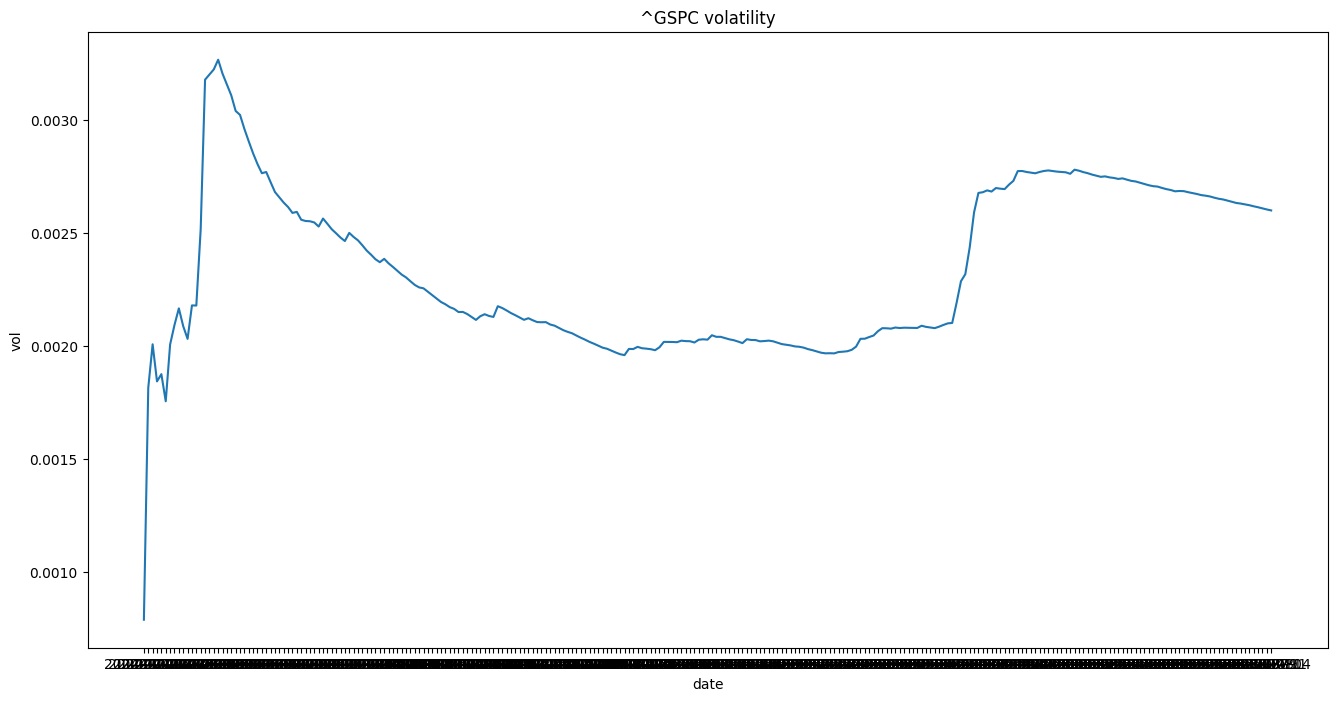

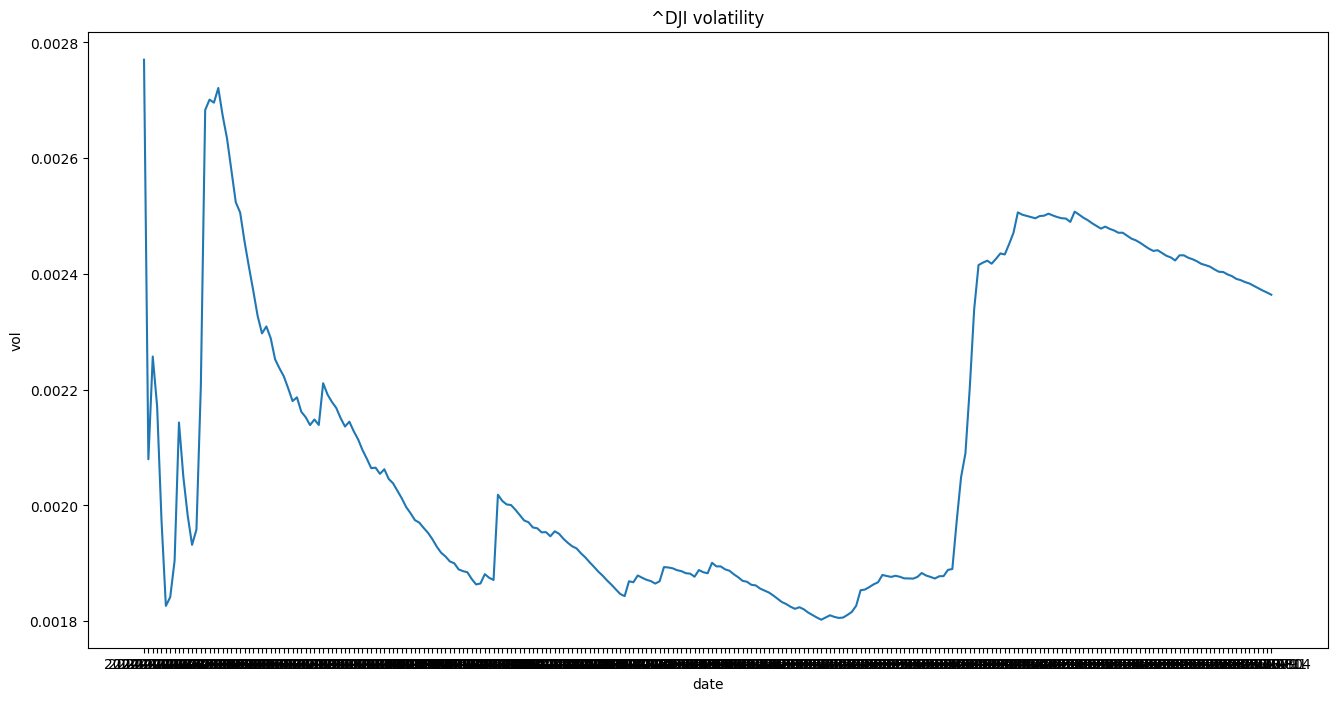

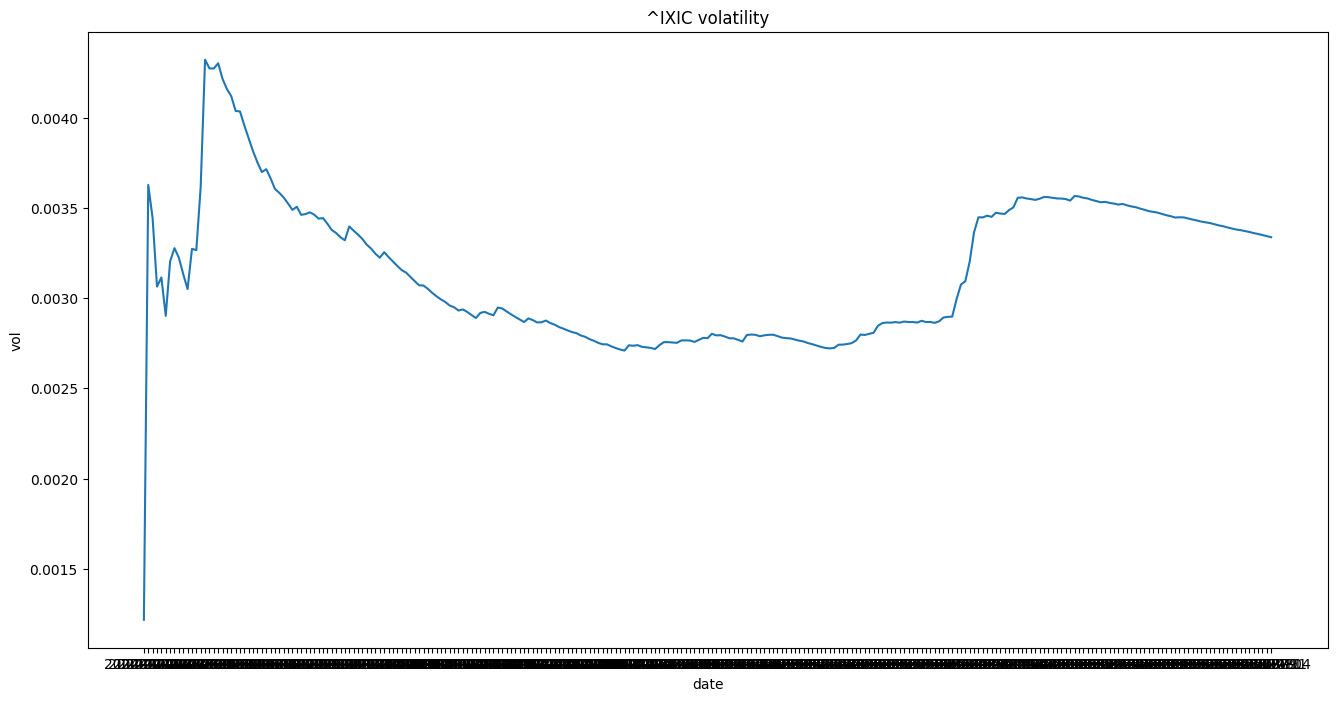

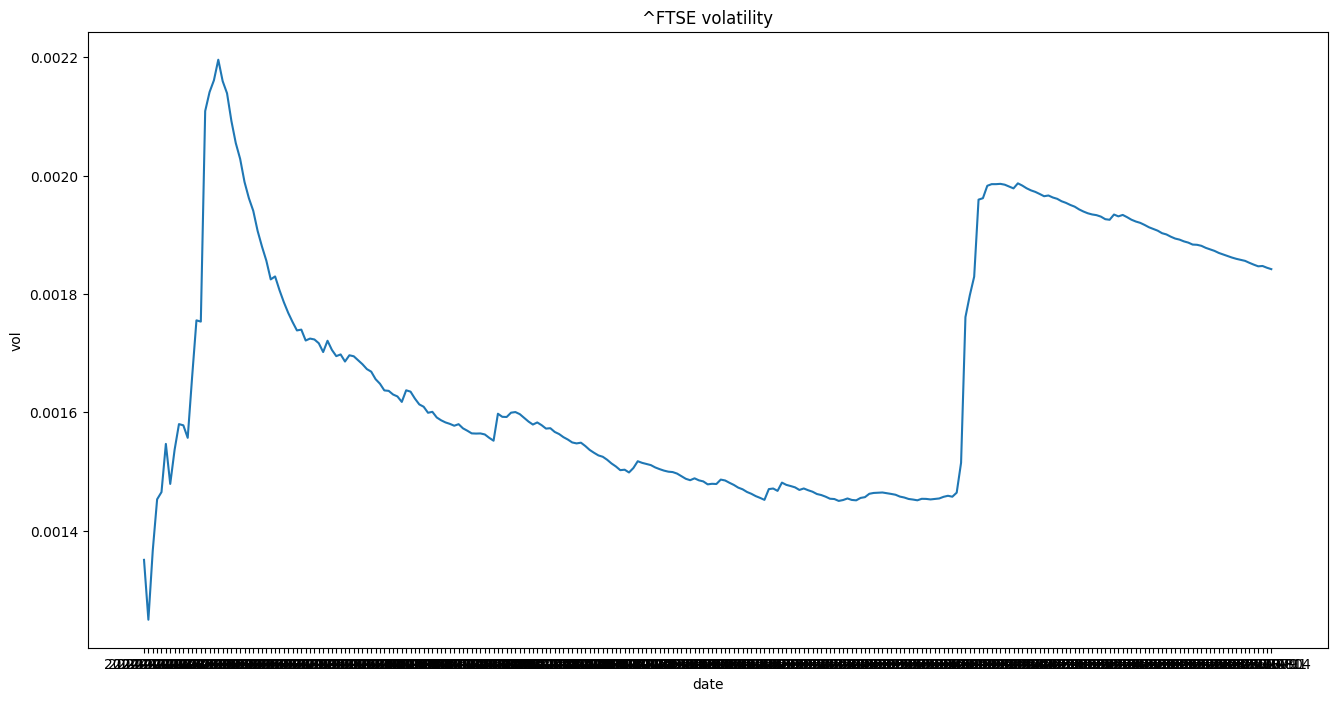

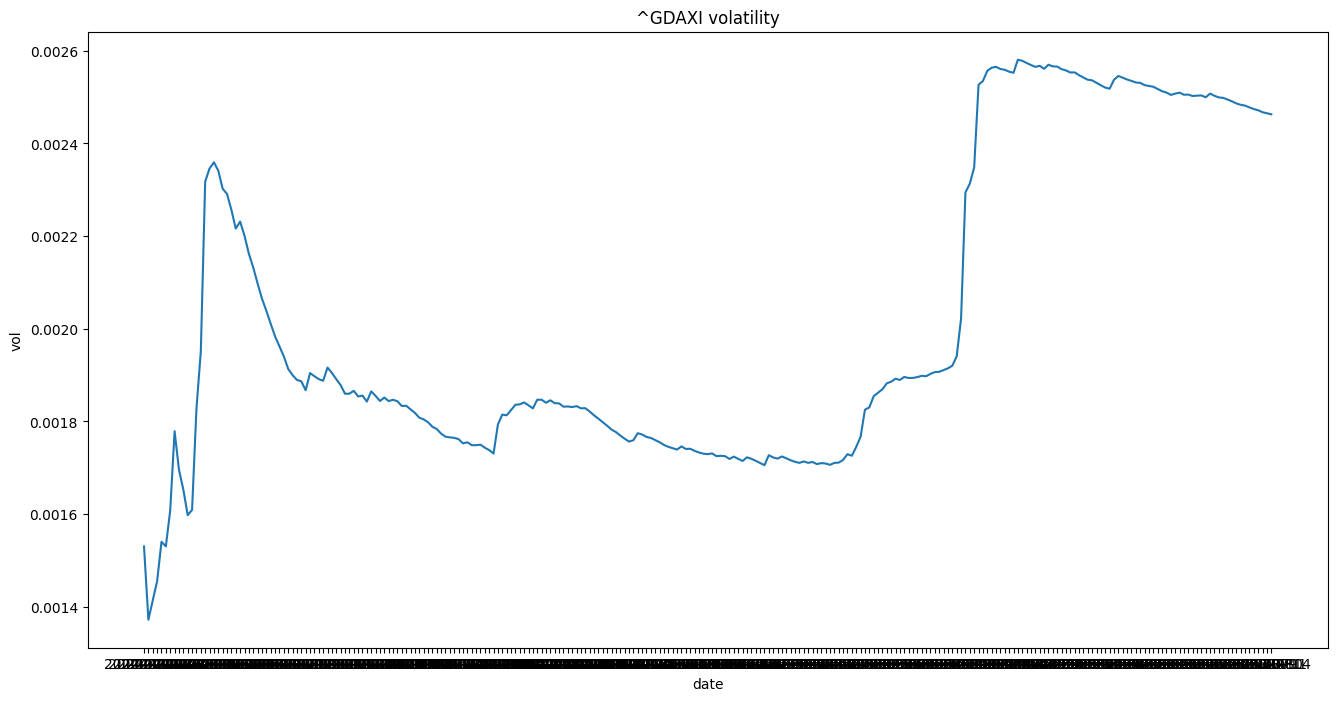

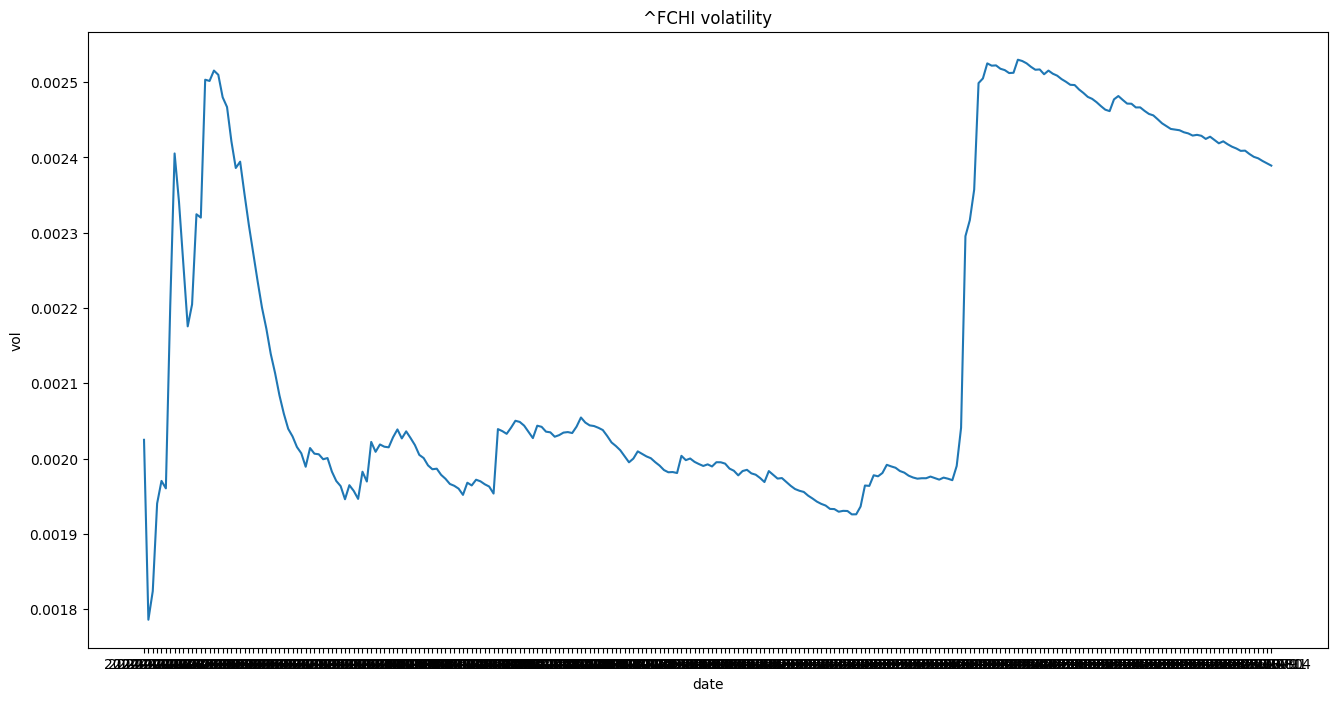

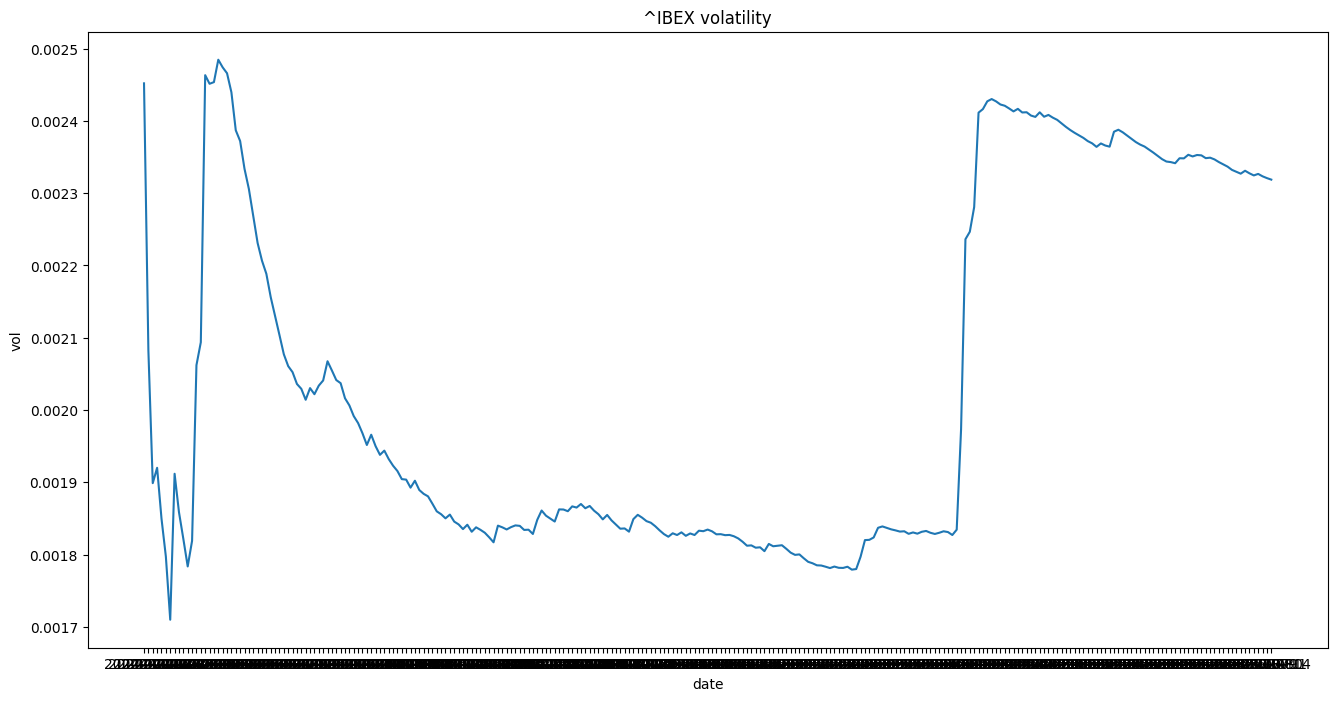

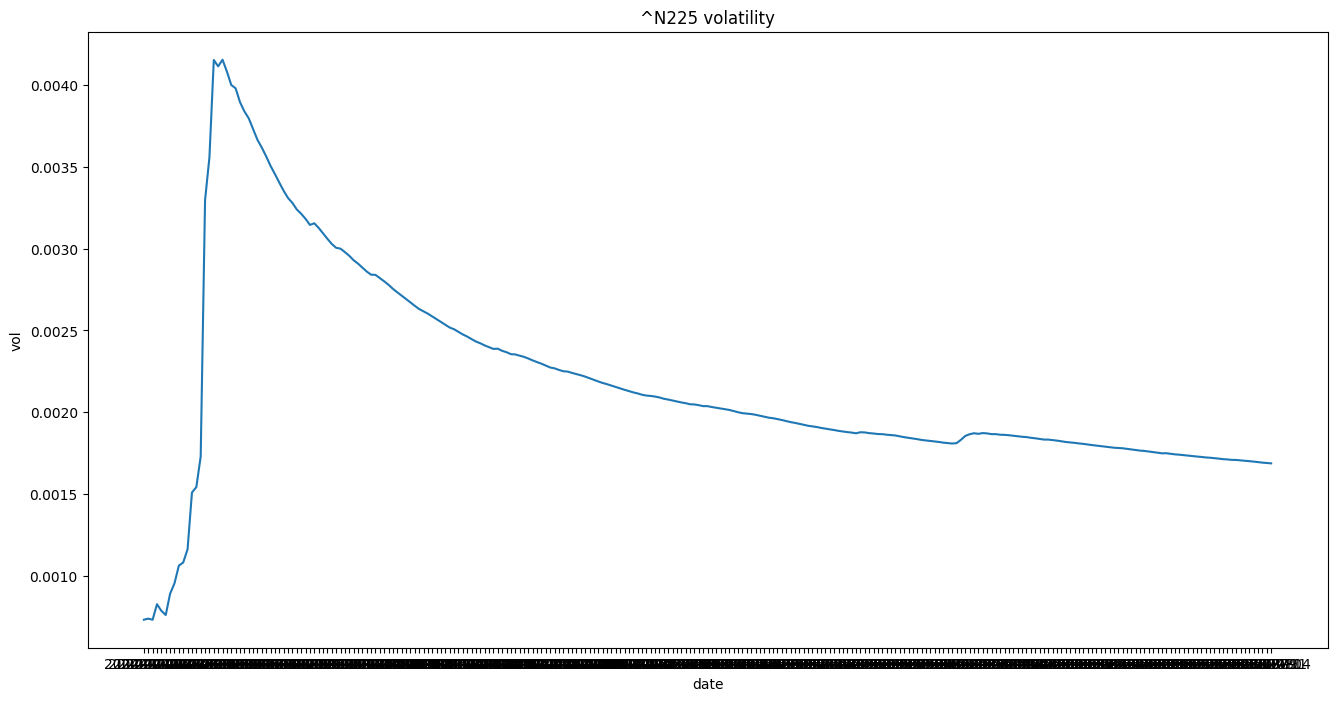

In [23]:
for tick in ticker:
    plt.figure(figsize=(16,8))
    plt.plot(dataset[tick])
    plt.title(f"{tick} volatility")
    plt.xlabel("date")
    plt.ylabel("vol")
    plt.show()

In [23]:
metrics = []


for tick in ticker:
    data = returns[tick]
    mean = data.mean()
    std = data.std()
    kurt = data.kurtosis()
    skew = data.skew()
    metrics = np.append(metrics, [mean, std, kurt, skew])

metrics = pd.DataFrame(metrics.reshape(len(ticker),4), index = ticker, columns = ["Mean", "Std", "Kurtosis", "Skewness"])
metrics

,Mean,Std,Kurtosis,Skewness
^GSPC,0.000570,0.011719,19.680665,1.053613
^DJI,0.000339,0.010541,14.985239,0.885643
^IXIC,0.000895,0.015162,16.893948,1.213194
^FTSE,0.000483,0.007442,13.822193,-1.734589
^GDAXI,0.000846,0.011036,3.568489,-0.357050
^FCHI,0.000365,0.010007,4.198749,-0.747286
^IBEX,0.001122,0.010212,7.268609,-1.196793
^N225,0.000872,0.013913,11.721797,0.508133
